# Exercise 2
## Part 1

In [4]:
import pandas as pd

df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None)

# Add column names
df.columns = ["Date", "Time", "Depth_m", "Temperature_C", "Salinity_PSU"]  # Replace with your actual column names

# Write to CSV
df.to_csv("CTD_profile_20081129_0652.csv", index=False)

print(df.head())

         Date   Time  Depth_m  Temperature_C  Salinity_PSU
0  11/29/2008  06:52        5          28.97         35.21
1  11/29/2008  06:52        6          28.98         35.21
2  11/29/2008  06:52        7          28.99         35.21
3  11/29/2008  06:52        8          28.96         35.21
4  11/29/2008  06:52        9          28.99         35.21


## Part 2 - Profiles

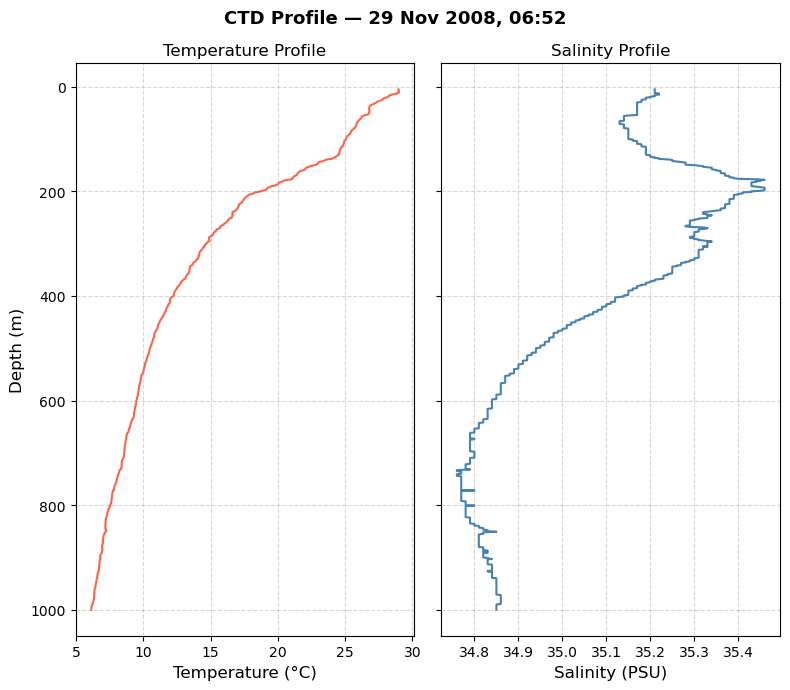

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv('CTD_profile_20081129_0652.csv')

# Create figure with two panels sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 7))

# Temperature profile
ax1.plot(df['Temperature_C'], df['Depth_m'], color='tomato', linewidth=1.5)
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_title('Temperature Profile')
ax1.invert_yaxis()
ax1.grid(True, linestyle='--', alpha=0.5)

# Salinity profile
ax2.plot(df['Salinity_PSU'], df['Depth_m'], color='steelblue', linewidth=1.5)
ax2.set_xlabel('Salinity (PSU)', fontsize=12)
ax2.set_title('Salinity Profile')
ax2.grid(True, linestyle='--', alpha=0.5)

# Overall title
fig.suptitle('CTD Profile — 29 Nov 2008, 06:52', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('CTD_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3 - Time series

In [ ]:
"""
Analysis script for SA Agulhas II cruise metocean data (2017)

Tasks:
1. Load CSV with datetime index and handle missing values.
2. Select data from departure up to July 4th (inclusive).
3. Plot temperature time series (grayscale).
4. Plot salinity histogram (30–35 PSU, 0.5 PSU bins).
5. Compute mean, std, and IQR for temperature and salinity.
6. Scatter plot of wind speed vs air temperature, colored by latitude.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Load data and set time index
# ---------------------------------------------------------------------
# Read CSV, parsing TIME_SERVER as datetime
df = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    na_values=["NULL"],
    parse_dates=["TIME_SERVER"]
)

# Set datetime index
df = df.set_index("TIME_SERVER")

# Convert latitude to decimal degrees (negative for Southern Hemisphere)
# LATITUDE is in degrees+minutes (ddmm.mmm)
lat_deg = (df["LATITUDE"] // 100) + (df["LATITUDE"] % 100) / 60
df["LAT_DECIMAL"] = -lat_deg  # Southern Hemisphere

In [9]:
# ---------------------------------------------------------------------
# 2. Select data from departure up to July 4th (inclusive)
# ---------------------------------------------------------------------
df_sel = df.loc[: "2017-07-04"]

# ---------------------------------------------------------------------
# 3. Plot time series of temperature (air temperature), grayscale
# ---------------------------------------------------------------------
plt.figure()
plt.plot(df_sel.index, df_sel["AIR_TEMPERATURE"], color="gray")
plt.xlabel("Time")
plt.ylabel("Air temperature (°C)")
plt.title("Air temperature time series (SA Agulhas II, 2017)")
plt.tight_layout()
plt.savefig("air_temperature_timeseries.png", dpi=300)
plt.close()

# ---------------------------------------------------------------------
# 4. Histogram of salinity (30–35 PSU, bins of 0.5)
# ---------------------------------------------------------------------
salinity = df_sel["TSG_SALINITY"].dropna()
bins = np.arange(30, 35.5, 0.5)

plt.figure()
plt.hist(salinity, bins=bins, color="gray", edgecolor="black")
plt.xlabel("Salinity (PSU)")
plt.ylabel("Frequency")
plt.title("Salinity distribution (30–35 PSU)")
plt.tight_layout()
plt.savefig("salinity_histogram.png", dpi=300)
plt.close()

In [10]:
# ---------------------------------------------------------------------
# 5. Mean, standard deviation, and interquartile range (IQR)
# ---------------------------------------------------------------------
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

stats = pd.DataFrame(
    {
        "Mean": [
            df_sel["AIR_TEMPERATURE"].mean(),
            df_sel["TSG_SALINITY"].mean(),
        ],
        "Standard Deviation": [
            df_sel["AIR_TEMPERATURE"].std(),
            df_sel["TSG_SALINITY"].std(),
        ],
        "IQR": [
            iqr(df_sel["AIR_TEMPERATURE"]),
            iqr(df_sel["TSG_SALINITY"]),
        ],
    },
    index=["Air temperature (°C)", "Salinity (PSU)"],
)

print(stats)

                           Mean  Standard Deviation        IQR
Air temperature (°C)   4.878271            6.692847  11.675000
Salinity (PSU)        33.110553            1.140150   1.272575


In [11]:
# ---------------------------------------------------------------------
# 6. Scatter plot: wind speed vs air temperature, colored by latitude
# ---------------------------------------------------------------------
plt.figure()
sc = plt.scatter(
    df_sel["WIND_SPEED_TRUE"],
    df_sel["AIR_TEMPERATURE"],
    c=df_sel["LAT_DECIMAL"],
    cmap="viridis",
    s=10
)
plt.xlabel("Wind speed (m s$^{-1}$)")
plt.ylabel("Air temperature (°C)")
plt.title("Wind speed vs air temperature (colored by latitude)")
plt.colorbar(sc, label="Latitude (°)")
plt.tight_layout()
plt.savefig("wind_vs_air_temperature_latitude.png", dpi=300)
plt.close()